# Lab Assignment 7
- Name: Sanjushree Rajan
- Reg. no.: BL.EN.U4AIE23130

**Objective:** Perform cepstral analysis on a speech signal to:
- Compute the real cepstrum
- Visualize and explain the cepstrum plot
- Estimate pitch (F0) from voiced frames
- Separate excitation and vocal tract contributions via liftering

---

## 0. Imports and Setup

In [49]:
import numpy as np
import scipy
import scipy.signal as signal
import scipy.io.wavfile as wavfile
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import librosa
import librosa.display
warnings.filterwarnings('ignore')

print('librosa available:', librosa.__version__)
print('numpy :', np.__version__)
print('scipy :', scipy.__version__)

librosa available: 0.11.0
numpy : 2.4.4
scipy : 1.17.1


---
## 1. Load / Generate Speech Signal

Loaded:  LJ025-0076.wav  |  fs=22050 Hz  |  duration=8.40s


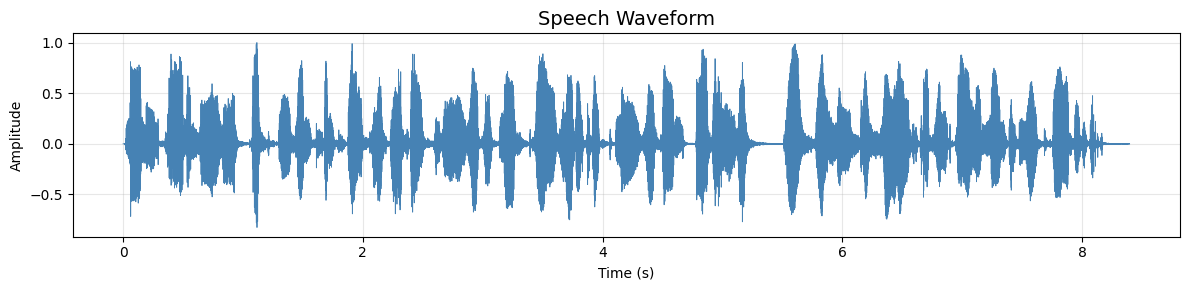

In [50]:
WAV_PATH = "LJ025-0076.wav"

def generate_synthetic_speech(duration=1.0, fs=16000, f0=120, formants=None):
    """
    Synthesise a voiced speech-like signal:
      - Glottal source: periodic impulse train at f0 Hz
      - Vocal tract: cascade of 2nd-order resonators at formant frequencies
    """
    if formants is None:
        # Typical vowel /a/ formant frequencies (Hz) and bandwidths (Hz)
        formants = [(800, 80), (1200, 100), (2500, 120), (3500, 150)]

    t = np.arange(int(duration * fs)) / fs

    # Glottal pulse train
    period_samples = int(fs / f0)
    source = np.zeros(len(t))
    source[::period_samples] = 1.0

    # Vocal tract filter (IIR cascade)
    speech = source.copy()
    for (fc, bw) in formants:
        b, a = signal.iirpeak(fc, fc / bw, fs)
        speech = signal.lfilter(b, a, speech)

    # Normalise
    speech = speech / np.max(np.abs(speech))
    return speech, fs


if WAV_PATH is not None:
    fs, data = wavfile.read(WAV_PATH)
    if data.ndim > 1:
        data = data[:, 0]          # mono
    data = data.astype(np.float64)
    data = data / np.max(np.abs(data))   # normalise
    speech, sr = data, fs
    print(f'Loaded:  {WAV_PATH}  |  fs={fs} Hz  |  duration={len(data)/fs:.2f}s')
else:
    speech, sr = generate_synthetic_speech(duration=1.0, fs=16000, f0=120)
    print(f'Using synthetic voiced speech  |  fs={sr} Hz  |  f0=120 Hz  |  duration=1.0 s')

# ── Quick waveform plot ──────────────────────────────────────────────────────
t_axis = np.arange(len(speech)) / sr
plt.figure(figsize=(12, 3))
plt.plot(t_axis, speech, linewidth=0.6, color='steelblue')
plt.title('Speech Waveform', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Frame the Signal

Speech is a **short-time stationary** process. We analyse it in frames of ~20–30 ms with 50 % overlap. A Hamming window minimises spectral leakage.

In [51]:
# ── Framing parameters ───────────────────────────────────────────────────────
FRAME_LEN_MS  = 25          # frame length in milliseconds
FRAME_SHIFT_MS = 10         # hop size in milliseconds

frame_len   = int(FRAME_LEN_MS  * sr / 1000)   # samples
frame_shift = int(FRAME_SHIFT_MS * sr / 1000)  # samples
window      = np.hamming(frame_len)

def frame_signal(x, frame_len, frame_shift, window):
    """Split signal into overlapping windowed frames."""
    n_frames = 1 + (len(x) - frame_len) // frame_shift
    frames = np.stack(
        [x[i*frame_shift : i*frame_shift + frame_len] * window
         for i in range(n_frames)]
    )
    return frames

frames = frame_signal(speech, frame_len, frame_shift, window)
print(f'Frame length : {frame_len} samples  ({FRAME_LEN_MS} ms)')
print(f'Frame shift  : {frame_shift} samples ({FRAME_SHIFT_MS} ms)')
print(f'Total frames : {frames.shape[0]}')

Frame length : 551 samples  (25 ms)
Frame shift  : 220 samples (10 ms)
Total frames : 840


---
## Task A — Compute the Real Cepstrum

The **real cepstrum** is defined as:

$$c[n] = \mathcal{F}^{-1}\{\log|\mathcal{F}\{x[n]\}|\}$$

**Steps:**
1. Apply FFT to each windowed frame.
2. Take the magnitude spectrum, apply a logarithm (base $e$).
3. Apply the IFFT (only the real part is retained).

The independent variable in the cepstral domain is called **quefrency** (units of seconds, analogous to lag/time).

In [52]:
def real_cepstrum(frame, nfft=None):
    """
    Compute the real cepstrum of a single frame.

    Parameters
    ----------
    frame : 1-D array  — windowed speech frame
    nfft  : int or None — FFT size (defaults to next power-of-2 ≥ len(frame))

    Returns
    -------
    cep         : real cepstrum (length nfft)
    quefrency   : quefrency axis in seconds
    log_spectrum: log-magnitude spectrum (for visualisation)
    freq_axis   : frequency axis in Hz
    """
    if nfft is None:
        nfft = int(2 ** np.ceil(np.log2(len(frame))))

    # Step 1 — DFT
    spectrum     = np.fft.rfft(frame, n=nfft)
    mag_spectrum = np.abs(spectrum)

    # Step 2 — log magnitude  (add small floor to avoid log(0))
    log_mag = np.log(mag_spectrum + 1e-10)

    # Step 3 — IFFT of log-spectrum  (symmetric → real result)
    log_full = np.concatenate([log_mag, log_mag[-2:0:-1]])  # mirror
    cep      = np.real(np.fft.ifft(log_full))

    quefrency = np.arange(nfft) / sr       # seconds
    freq_axis = np.fft.rfftfreq(nfft, 1/sr)

    return cep, quefrency, log_mag, freq_axis


# Compute cepstrum for every frame
NFFT = int(2 ** np.ceil(np.log2(frame_len)))
all_cepstra   = np.zeros((frames.shape[0], NFFT))
all_logspec   = np.zeros((frames.shape[0], NFFT // 2 + 1))

for i, frm in enumerate(frames):
    cep, _, lms, _ = real_cepstrum(frm, nfft=NFFT)
    all_cepstra[i] = cep
    all_logspec[i] = lms

print(f'Cepstrum matrix shape : {all_cepstra.shape}  (frames × quefrency bins)')
print(f'FFT size (NFFT)       : {NFFT}')

Cepstrum matrix shape : (840, 1024)  (frames × quefrency bins)
FFT size (NFFT)       : 1024


---
## Task B — Plot the Cepstrum of a Selected Frame and Explain

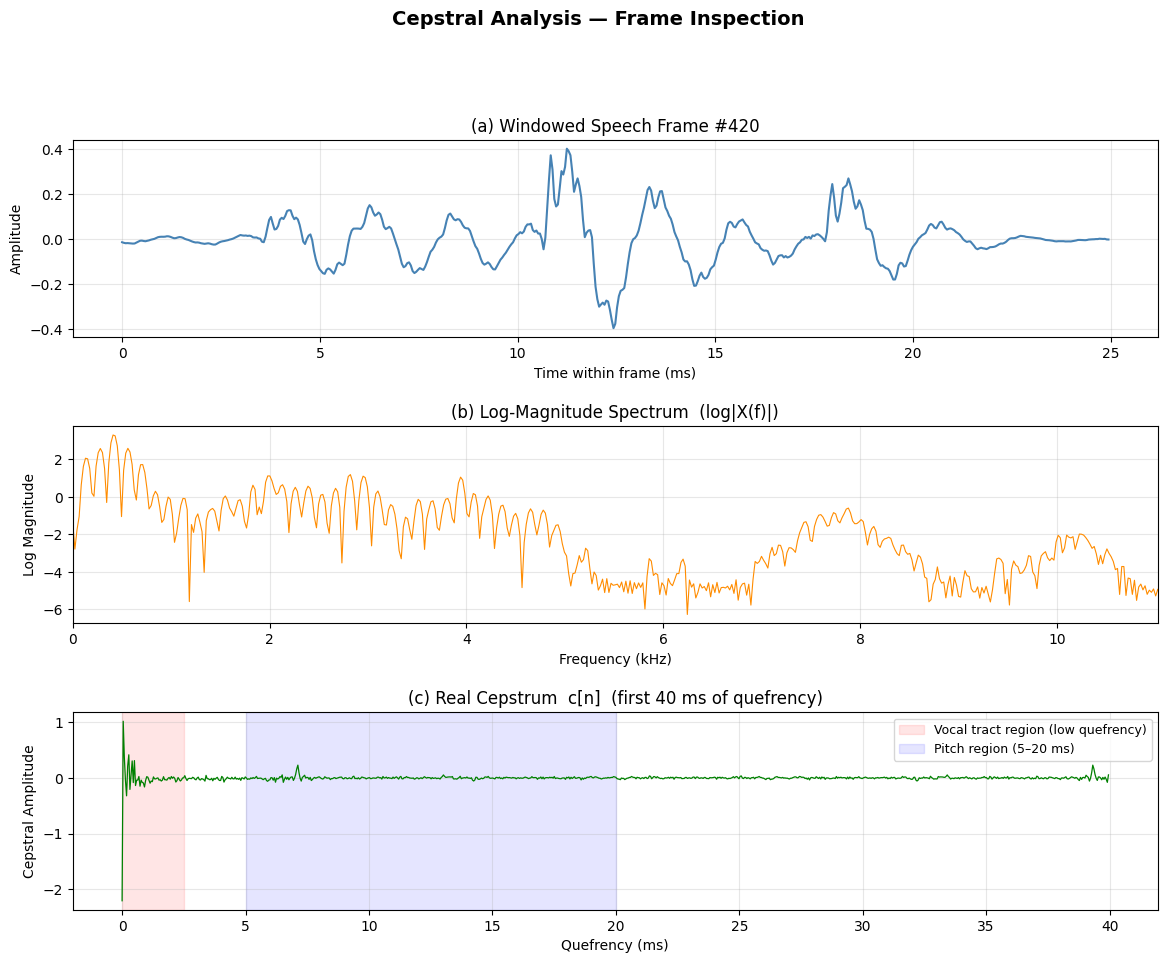


=== Explanation of the Cepstrum Plot ===

The SOURCE-FILTER model of speech production states:
    X(ω) = G(ω) · H(ω)
where G(ω) is the glottal excitation and H(ω) is the vocal-tract filter.

Taking logarithms converts this product into a SUM:
    log|X(ω)| = log|G(ω)| + log|H(ω)|

Applying an IFFT (the 'cepstrum') separates these additive components
into DIFFERENT QUEFRENCY REGIONS:

  • LOW quefrency (0 – ~2.5 ms)  → Slow spectral envelope = VOCAL TRACT
    The first few cepstral coefficients encode formant structure.

  • HIGH quefrency (5 – 20 ms)   → Fine spectral periodicity = PITCH PULSES
    A prominent peak here indicates the pitch period T0 = 1/F0.

  • The large c[0] value reflects the overall signal energy (DC of spectrum).



In [53]:
# ── Choose a frame near the middle of the utterance ─────────────────────────
frame_idx = frames.shape[0] // 2

cep, quefrency, log_mag, freq_axis = real_cepstrum(frames[frame_idx], nfft=NFFT)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# (a) windowed frame
ax0 = fig.add_subplot(gs[0])
t_frame = np.arange(frame_len) / sr * 1000
ax0.plot(t_frame, frames[frame_idx], color='steelblue')
ax0.set_title(f'(a) Windowed Speech Frame #{frame_idx}', fontsize=12)
ax0.set_xlabel('Time within frame (ms)')
ax0.set_ylabel('Amplitude')
ax0.grid(True, alpha=0.3)

# (b) log-magnitude spectrum
ax1 = fig.add_subplot(gs[1])
ax1.plot(freq_axis / 1000, log_mag, color='darkorange', linewidth=0.8)
ax1.set_title('(b) Log-Magnitude Spectrum  (log|X(f)|)', fontsize=12)
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('Log Magnitude')
ax1.set_xlim([0, sr / 2 / 1000])
ax1.grid(True, alpha=0.3)

# (c) real cepstrum — show first 40 ms
max_q_ms = 40
max_q_samp = int(max_q_ms * sr / 1000)
ax2 = fig.add_subplot(gs[2])
ax2.plot(quefrency[:max_q_samp] * 1000, cep[:max_q_samp], color='green', linewidth=0.9)
ax2.set_title('(c) Real Cepstrum  c[n]  (first 40 ms of quefrency)', fontsize=12)
ax2.set_xlabel('Quefrency (ms)')
ax2.set_ylabel('Cepstral Amplitude')
ax2.axvspan(0, 2.5, alpha=0.1, color='red',  label='Vocal tract region (low quefrency)')
ax2.axvspan(5, 20, alpha=0.1, color='blue', label='Pitch region (5–20 ms)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Cepstral Analysis — Frame Inspection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
=== Explanation of the Cepstrum Plot ===

The SOURCE-FILTER model of speech production states:
    X(ω) = G(ω) · H(ω)
where G(ω) is the glottal excitation and H(ω) is the vocal-tract filter.

Taking logarithms converts this product into a SUM:
    log|X(ω)| = log|G(ω)| + log|H(ω)|

Applying an IFFT (the 'cepstrum') separates these additive components
into DIFFERENT QUEFRENCY REGIONS:

  • LOW quefrency (0 – ~2.5 ms)  → Slow spectral envelope = VOCAL TRACT
    The first few cepstral coefficients encode formant structure.

  • HIGH quefrency (5 – 20 ms)   → Fine spectral periodicity = PITCH PULSES
    A prominent peak here indicates the pitch period T0 = 1/F0.

  • The large c[0] value reflects the overall signal energy (DC of spectrum).
""")

---
## Task C — Voiced Frame Detection and Pitch Estimation

**Theory:**
For voiced speech, the glottal excitation is periodic with period $T_0 = 1/F_0$. In the cepstrum, this periodicity appears as a prominent peak at quefrency $\hat{n}/f_s = T_0$.

- Typical pitch range: $F_0 \in [50, 400]$ Hz  →  $T_0 \in [2.5, 20]$ ms
- We detect **voiced** frames by checking if the peak cepstral value in this range exceeds a threshold.

In [54]:
# ── Pitch search range ───────────────────────────────────────────────────────
F0_MIN, F0_MAX = 50, 400          # Hz
q_min = int(sr / F0_MAX)          # samples  (≈ 5 ms for F0_MAX=200, sr=16000)
q_max = int(sr / F0_MIN)          # samples  (≈ 20 ms for F0_MIN=80)
VOICED_THRESHOLD = 0.3            # cepstral peak amplitude threshold

def estimate_pitch(cep, sr, q_min, q_max, threshold=0.3):
    """
    Estimate F0 from real cepstrum.
    Returns (is_voiced, pitch_period_samples, F0_Hz)
    """
    segment = cep[q_min:q_max + 1]
    peak_rel_idx = np.argmax(segment)
    peak_val     = segment[peak_rel_idx]
    peak_abs_idx = peak_rel_idx + q_min

    is_voiced = peak_val > threshold
    T0_samples = peak_abs_idx
    F0 = sr / T0_samples if T0_samples > 0 else 0.0

    return is_voiced, T0_samples, F0, peak_val


# ── Run on all frames ─────────────────────────────────────────────────────────
voiced_flags = []
pitch_hz     = []
T0_list      = []
peak_vals    = []

for cep in all_cepstra:
    iv, T0, f0, pv = estimate_pitch(cep, sr, q_min, q_max, VOICED_THRESHOLD)
    voiced_flags.append(iv)
    pitch_hz.append(f0 if iv else np.nan)
    T0_list.append(T0)
    peak_vals.append(pv)

voiced_flags = np.array(voiced_flags)
pitch_hz     = np.array(pitch_hz)

n_voiced = voiced_flags.sum()
print(f'Total frames   : {len(voiced_flags)}')
print(f'Voiced frames  : {n_voiced} ({100*n_voiced/len(voiced_flags):.1f}%)')

if n_voiced > 0:
    valid = pitch_hz[voiced_flags]
    print(f'\nF0 statistics (voiced frames):')
    print(f'  Mean  F0 : {np.nanmean(valid):.1f} Hz')
    print(f'  Median F0 : {np.nanmedian(valid):.1f} Hz')
    print(f'  Min F0   : {np.nanmin(valid):.1f} Hz')
    print(f'  Max F0   : {np.nanmax(valid):.1f} Hz')

    # Example: show details for the most confident voiced frame
    best_frame = np.argmax(np.array(peak_vals) * voiced_flags.astype(float))
    bT0 = T0_list[best_frame]
    bF0 = pitch_hz[best_frame]
    print(f'\nBest voiced frame #{best_frame}:')
    print(f'  Pitch period T0 = {bT0} samples = {bT0/sr*1000:.2f} ms')
    print(f'  Fundamental freq F0 = {bF0:.1f} Hz')

Total frames   : 840
Voiced frames  : 68 (8.1%)

F0 statistics (voiced frames):
  Mean  F0 : 233.3 Hz
  Median F0 : 245.0 Hz
  Min F0   : 152.1 Hz
  Max F0   : 334.1 Hz

Best voiced frame #146:
  Pitch period T0 = 84 samples = 3.81 ms
  Fundamental freq F0 = 262.5 Hz


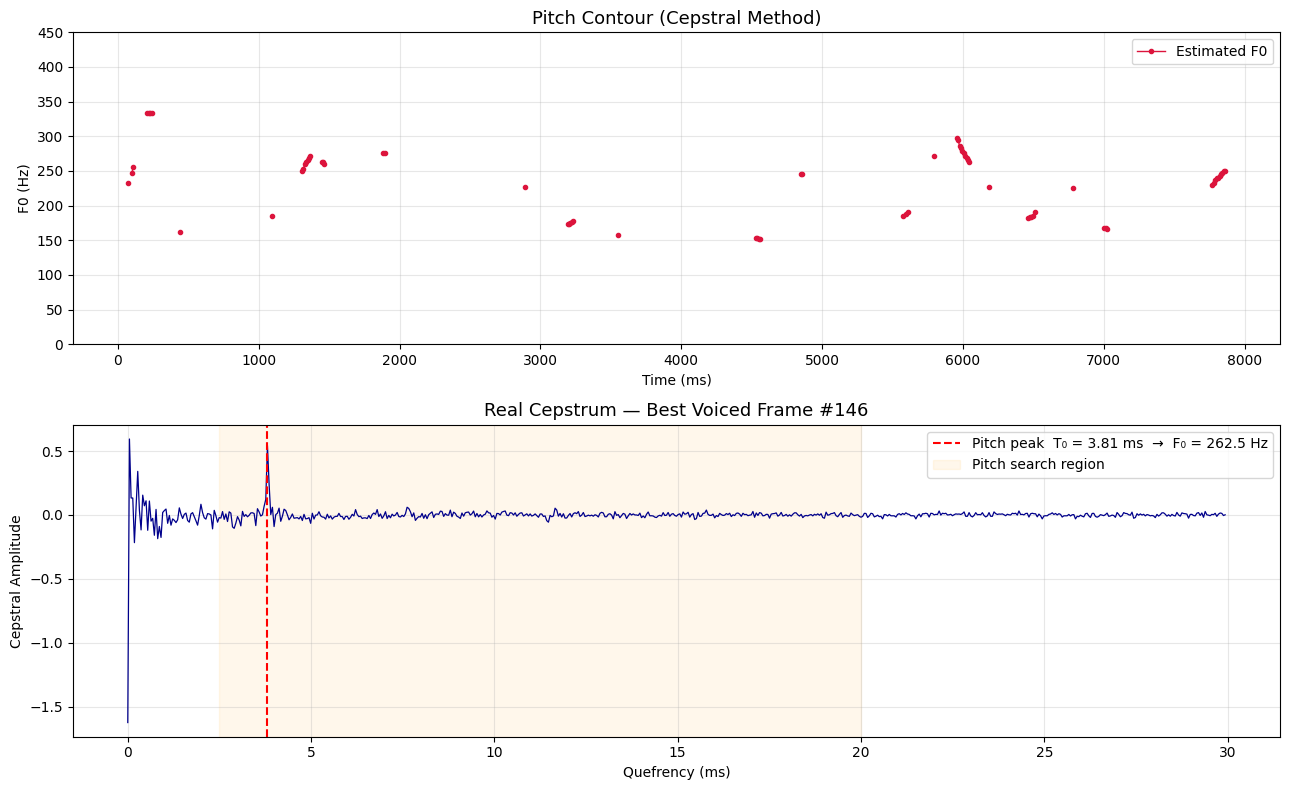

In [55]:
# ── Plot pitch contour and cepstrum of best voiced frame ─────────────────────
time_frames = np.arange(len(pitch_hz)) * frame_shift / sr * 1000  # ms

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Pitch contour
ax = axes[0]
ax.plot(time_frames, pitch_hz, 'o-', color='crimson', markersize=3, linewidth=1, label='Estimated F0')
ax.set_title('Pitch Contour (Cepstral Method)', fontsize=13)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('F0 (Hz)')
ax.set_ylim([0, F0_MAX + 50])
ax.legend()
ax.grid(True, alpha=0.3)

# Cepstrum of best voiced frame with pitch peak annotated
ax2 = axes[1]
cep_best = all_cepstra[best_frame]
max_q_ms = 30
max_q_s  = int(max_q_ms * sr / 1000)
qaxis_ms = np.arange(max_q_s) / sr * 1000

ax2.plot(qaxis_ms, cep_best[:max_q_s], color='darkblue', linewidth=0.9)
ax2.axvline(bT0 / sr * 1000, color='red', linestyle='--',
            label=f'Pitch peak  T₀ = {bT0/sr*1000:.2f} ms  →  F₀ = {bF0:.1f} Hz')
ax2.axvspan(q_min/sr*1000, q_max/sr*1000, alpha=0.08, color='orange', label='Pitch search region')
ax2.set_title(f'Real Cepstrum — Best Voiced Frame #{best_frame}', fontsize=13)
ax2.set_xlabel('Quefrency (ms)')
ax2.set_ylabel('Cepstral Amplitude')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task C — Inference

- The pitch period $T_0$ is the quefrency at which a prominent **rahmonic** (cepstral peak) appears in the 5–20 ms range.
- $F_0 = 1/T_0$ gives the fundamental frequency.
- Frames with no clear rahmonic (or a weak one below the threshold) are classified as **unvoiced**.
- The cepstral method is robust because the pitch contribution and the vocal-tract contribution are well-separated in quefrency.

---
## Task D — Cepstral Liftering: Separating Excitation and Vocal Tract

**Liftering** is the cepstral analog of filtering:

| Domain   | Operation |
|----------|----------|
| Time     | Filtering (windowing in frequency) |
| Quefrency| Liftering (windowing in cepstrum)  |

A **low-pass lifter** (short quefrency window) keeps only the slowly-varying log-spectrum → **vocal tract envelope**.

A **high-pass lifter** (remove low quefrency) retains the fine periodic structure → **excitation (glottal source)**.

In [56]:
def lifter(cep, cutoff, lifter_type='low'):
    """
    Apply a rectangular lifter in the quefrency domain.

    Parameters
    ----------
    cep         : real cepstrum (length N)
    cutoff      : quefrency cutoff in samples
    lifter_type : 'low'  → keeps 0 … cutoff  (vocal tract)
                  'high' → keeps cutoff … N/2 (excitation)

    Returns
    -------
    log_spec_liftered : reconstructed log-magnitude spectrum
    cep_liftered      : liftered cepstrum
    """
    N = len(cep)
    win = np.zeros(N)

    if lifter_type == 'low':
        win[0:cutoff + 1] = 1.0
        win[N - cutoff:N] = 1.0      # symmetric
    else:  # high
        win[:] = 1.0
        win[0:cutoff] = 0.0
        win[N - cutoff + 1:N] = 0.0

    cep_liftered = cep * win

    # Reconstruct log-spectrum via DFT of liftered cepstrum
    log_spec_full   = np.real(np.fft.fft(cep_liftered))
    log_spec_half   = log_spec_full[:N // 2 + 1]

    return log_spec_half, cep_liftered


# ── Liftering on the best voiced frame ───────────────────────────────────────
LIFTER_CUTOFF_MS = 2.0    # quefrency cutoff in ms (typical: 1–3 ms)
lifter_cutoff_samples = int(LIFTER_CUTOFF_MS * sr / 1000)

cep_best   = all_cepstra[best_frame]
freq_axis  = np.fft.rfftfreq(NFFT, 1/sr)
quefrency  = np.arange(NFFT) / sr * 1000   # ms

ls_vt, cep_vt   = lifter(cep_best, lifter_cutoff_samples, 'low')   # vocal tract
ls_exc, cep_exc = lifter(cep_best, lifter_cutoff_samples, 'high')  # excitation

# Original log spectrum (for comparison)
orig_log_spec = all_logspec[best_frame]

print(f'Lifter cutoff : {lifter_cutoff_samples} samples = {LIFTER_CUTOFF_MS} ms')
print(f'Vocal-tract lifter retains  quefrency 0 – {LIFTER_CUTOFF_MS} ms')
print(f'Excitation lifter retains   quefrency {LIFTER_CUTOFF_MS} ms – {NFFT/sr*1000/2:.1f} ms')

Lifter cutoff : 44 samples = 2.0 ms
Vocal-tract lifter retains  quefrency 0 – 2.0 ms
Excitation lifter retains   quefrency 2.0 ms – 23.2 ms


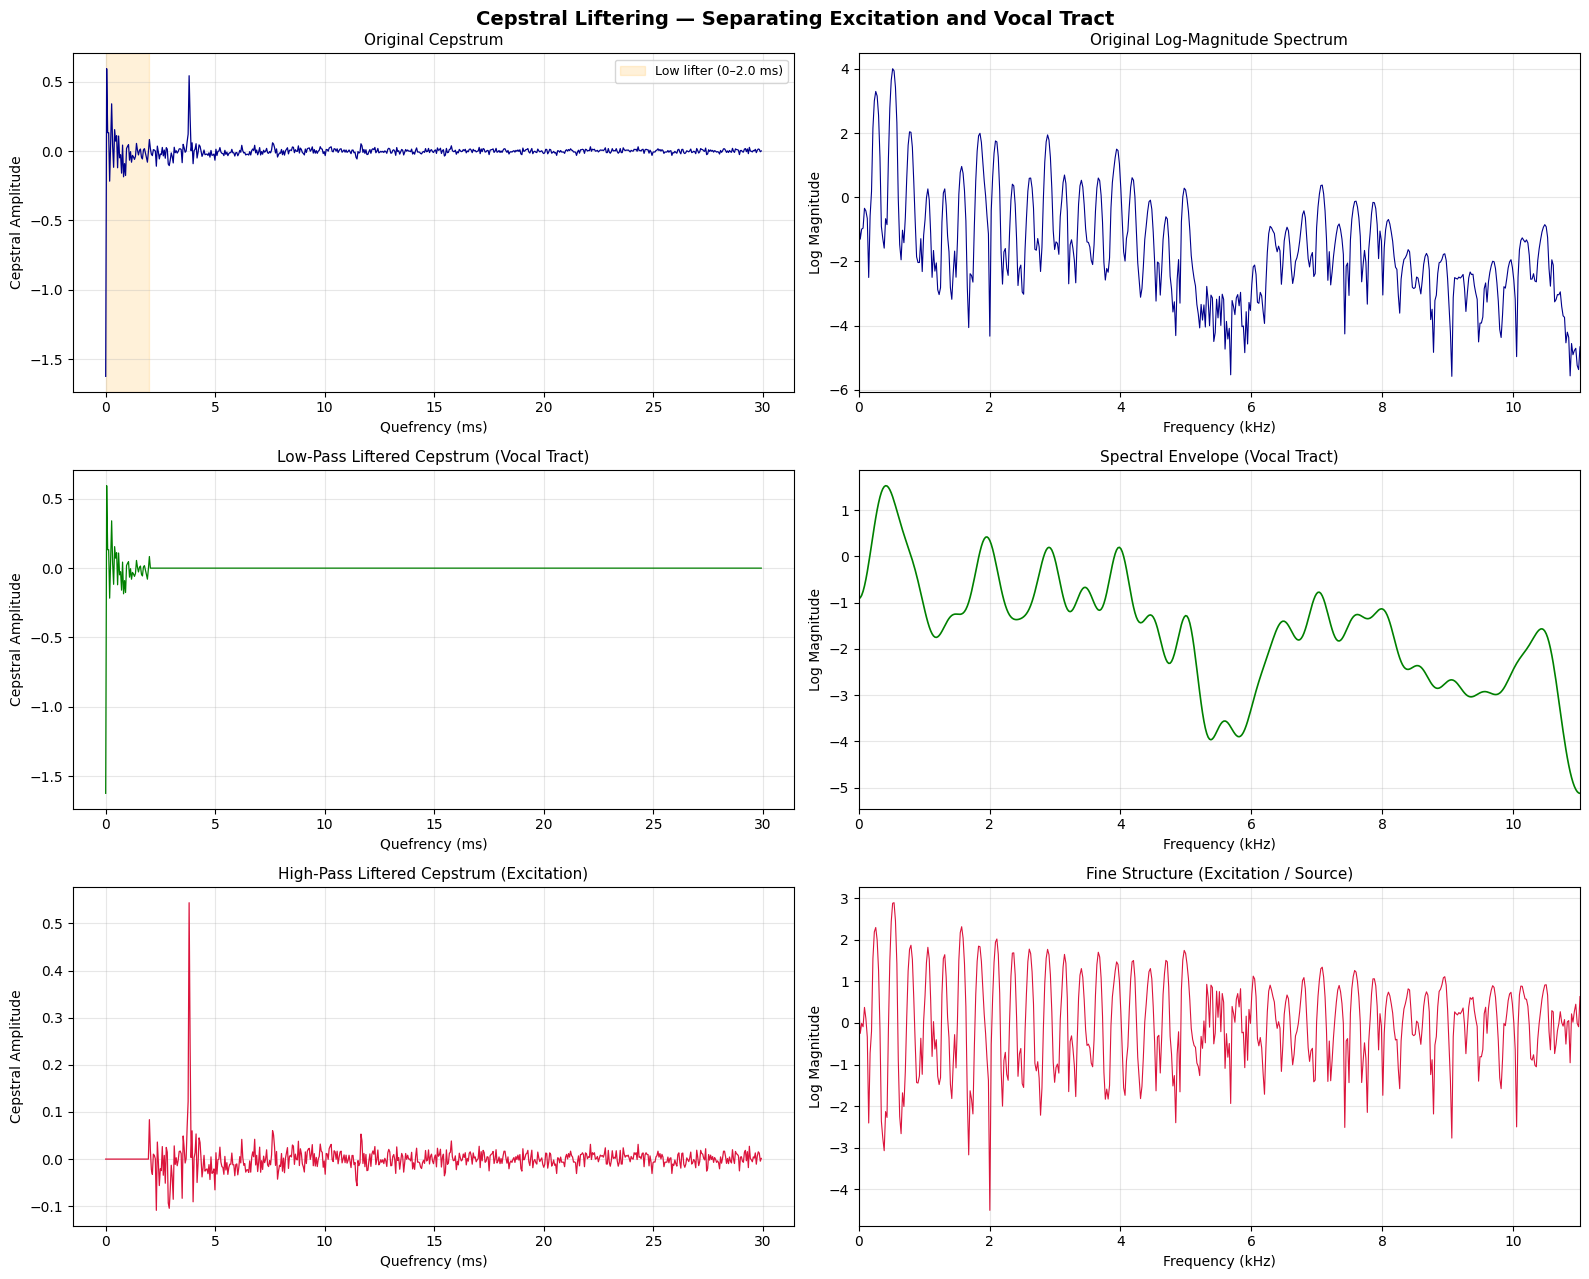

In [57]:
# ── Visualise liftering results ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 13))

max_q_show = int(30 * sr / 1000)

# ─ Column 1: cepstra ──────────────────────────────────────────────────────────
axes[0, 0].plot(quefrency[:max_q_show], cep_best[:max_q_show], color='darkblue', linewidth=0.9)
axes[0, 0].axvspan(0, LIFTER_CUTOFF_MS, alpha=0.15, color='orange', label=f'Low lifter (0–{LIFTER_CUTOFF_MS} ms)')
axes[0, 0].set_title('Original Cepstrum', fontsize=11)
axes[0, 0].set_xlabel('Quefrency (ms)'); axes[0, 0].set_ylabel('Cepstral Amplitude')
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(quefrency[:max_q_show], cep_vt[:max_q_show], color='green', linewidth=0.9)
axes[1, 0].set_title(f'Low-Pass Liftered Cepstrum (Vocal Tract)', fontsize=11)
axes[1, 0].set_xlabel('Quefrency (ms)'); axes[1, 0].set_ylabel('Cepstral Amplitude')
axes[1, 0].grid(True, alpha=0.3)

axes[2, 0].plot(quefrency[:max_q_show], cep_exc[:max_q_show], color='crimson', linewidth=0.9)
axes[2, 0].set_title(f'High-Pass Liftered Cepstrum (Excitation)', fontsize=11)
axes[2, 0].set_xlabel('Quefrency (ms)'); axes[2, 0].set_ylabel('Cepstral Amplitude')
axes[2, 0].grid(True, alpha=0.3)

# ─ Column 2: reconstructed log-spectra ───────────────────────────────────────
fkHz = freq_axis / 1000

axes[0, 1].plot(fkHz, orig_log_spec, color='darkblue', linewidth=0.8)
axes[0, 1].set_title('Original Log-Magnitude Spectrum', fontsize=11)
axes[0, 1].set_xlabel('Frequency (kHz)'); axes[0, 1].set_ylabel('Log Magnitude')
axes[0, 1].set_xlim([0, sr/2/1000]); axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].plot(fkHz, ls_vt, color='green', linewidth=1.2)
axes[1, 1].set_title('Spectral Envelope (Vocal Tract)', fontsize=11)
axes[1, 1].set_xlabel('Frequency (kHz)'); axes[1, 1].set_ylabel('Log Magnitude')
axes[1, 1].set_xlim([0, sr/2/1000]); axes[1, 1].grid(True, alpha=0.3)

axes[2, 1].plot(fkHz, ls_exc, color='crimson', linewidth=0.8)
axes[2, 1].set_title('Fine Structure (Excitation / Source)', fontsize=11)
axes[2, 1].set_xlabel('Frequency (kHz)'); axes[2, 1].set_ylabel('Log Magnitude')
axes[2, 1].set_xlim([0, sr/2/1000]); axes[2, 1].grid(True, alpha=0.3)

plt.suptitle('Cepstral Liftering — Separating Excitation and Vocal Tract', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

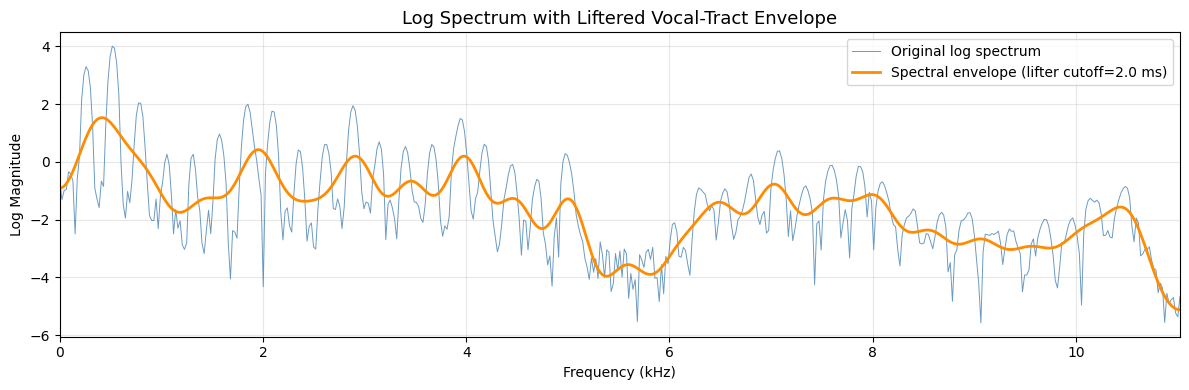

In [58]:
# ── Overlay: original + vocal-tract envelope ──────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(fkHz, orig_log_spec,  color='steelblue', linewidth=0.7,  alpha=0.8, label='Original log spectrum')
plt.plot(fkHz, ls_vt,          color='darkorange', linewidth=2.0, label=f'Spectral envelope (lifter cutoff={LIFTER_CUTOFF_MS} ms)')
plt.title('Log Spectrum with Liftered Vocal-Tract Envelope', fontsize=13)
plt.xlabel('Frequency (kHz)')
plt.ylabel('Log Magnitude')
plt.xlim([0, sr / 2 / 1000])
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Task E — Detailed Inferences

### E.1 — Real Cepstrum (Task A)

The real cepstrum maps the product relationship between vocal-tract and excitation components (in the frequency domain) into a **sum relationship** in the quefrency domain through the chain:

$$\text{Signal} \xrightarrow{\text{FFT}} \text{Spectrum} \xrightarrow{\log|\cdot|} \text{Log-mag} \xrightarrow{\text{IFFT}} \text{Cepstrum}$$

This is mathematically justified by the source-filter model: $\log|X(\omega)| = \log|H(\omega)| + \log|G(\omega)|$, and since these two components live at very different quefrency scales, they become separable.

---

### E.2 — Cepstrum Plot (Task B)

| Region | Quefrency | Physical Meaning |
|--------|-----------|------------------|
| c[0]   | 0 ms      | Log-energy of the frame |
| c[1..L]| 0 – ~2 ms | Slow spectral envelope → formant structure (vocal tract) |
| Rahmonic | 5 – 20 ms | Cepstral peak at $T_0$ → fundamental period of voiced speech |

The log-magnitude spectrum shows **formant peaks** as broad resonances and **harmonic lines** as fine periodic ripples. The IFFT in the cepstrum maps the formants to low quefrency and the harmonics (whose spacing equals $F_0$) to a peak at $T_0 = 1/F_0$.

---

### E.3 — Pitch Estimation (Task C)

- **Voiced frames** exhibit a clearly dominant rahmonic in the 5–20 ms pitch range. The quefrency of this peak equals the pitch period $T_0$, and $F_0 = f_s / n_0$ where $n_0$ is the peak index in samples.
- **Unvoiced frames** (fricatives, silences) show no such organised peak; the cepstrum is nearly flat in the pitch region.
- The cepstral method is a **robust, single-frame** pitch estimator because it inherently separates the pitch peak from the spectral-envelope contribution.

---

### E.4 — Cepstral Liftering (Task D)

**Low-pass lifter (vocal-tract):**
- Retaining only the first few quefrency samples (0 – ~2 ms) reconstructs a smooth log-spectrum that traces the **formant envelope**.
- This is the basis for **MFCC feature extraction** in speech recognition — the low cepstral coefficients encode formant positions without pitch information.

**High-pass lifter (excitation):**
- Removing the low quefrency part isolates the **fine harmonic structure** of voiced speech.
- The reconstructed spectrum shows a comb-like pattern at multiples of $F_0$, representing the glottal source.

**Key observation:** The two reconstructed spectra sum back (approximately) to the original log-spectrum, confirming that liftering successfully decomposes the signal in accordance with the source-filter model.

**Practical impact:** A small lifter cutoff produces a very smooth envelope (suitable for ASR features). A larger cutoff includes some pitch harmonics in the envelope estimate, making it noisier. The choice of $L \approx 1.5$–$3$ ms is a standard trade-off.

---

### E.5 — Summary Table

| Task | Method | Key Result |
|------|--------|------------|
| Real cepstrum | FFT → log|·| → IFFT | Separates source & filter into different quefrency bands |
| Cepstrum plot | Frame analysis | c[0] = energy; low-q = formants; rahmonic = pitch |
| Pitch estimation | Peak in 5–20 ms range | $T_0$ in ms; $F_0 = 1/T_0$ Hz; robust voiced/unvoiced detection |
| Liftering | Rectangular window in quefrency | LP → vocal-tract envelope; HP → excitation structure |

In [59]:
# ── Final summary printout ─────────────────────────────────────────────────
print('=== EXPERIMENT SUMMARY ===')
print(f'Sampling rate          : {sr} Hz')
print(f'Frame length           : {frame_len} samples  ({FRAME_LEN_MS} ms)')
print(f'Frame shift            : {frame_shift} samples ({FRAME_SHIFT_MS} ms)')
print(f'Total frames analysed  : {len(voiced_flags)}')
print(f'Voiced frames          : {n_voiced} ({100*n_voiced/len(voiced_flags):.1f}%)')
if n_voiced > 0:
    print(f'Mean F0 (voiced)       : {np.nanmean(pitch_hz):.1f} Hz')
    print(f'Pitch period at peak   : {bT0} samples = {bT0/sr*1000:.2f} ms')
print(f'Lifter cutoff          : {lifter_cutoff_samples} samples = {LIFTER_CUTOFF_MS} ms')

=== EXPERIMENT SUMMARY ===
Sampling rate          : 22050 Hz
Frame length           : 551 samples  (25 ms)
Frame shift            : 220 samples (10 ms)
Total frames analysed  : 840
Voiced frames          : 68 (8.1%)
Mean F0 (voiced)       : 233.3 Hz
Pitch period at peak   : 84 samples = 3.81 ms
Lifter cutoff          : 44 samples = 2.0 ms
